## Imports

In [2]:
from __future__ import annotations

import os
import copy
import random
import itertools
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy.stats import randint, uniform

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV, RandomizedSearchCV, ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss, log_loss

import moexalgo
from moexalgo import Ticker
import moexalgo.engines.currency
from moexalgo import Market

from src.market_ml.preprocessing import _download_feature, _usdrub, _stock, _concat, rolling_zscore, rolling_beta, _basic_features, _context_features, _flow_trades, _regime_features, get_feature_groups,  build_feature_list, _correlation
from src.market_ml.backtest import backtest_probs, print_bt_report, plot_bt, confidence_report
from src.market_ml.train_utils import eval, best_threshold, fearure_importance
from src.market_ml.dataset import make_target, train_test_valid_split, walk_forward_split

In [3]:
SEED = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import warnings
warnings.filterwarnings("ignore")

## Functions

In [ ]:
def calibrate_probs(calib_probs, y_calib, eval_probs, method='platt'):
    calib_probs = np.asarray(calib_probs, dtype=float)
    eval_probs = np.asarray(eval_probs, dtype=float)
    y_calib = np.asarray(y_calib, dtype=int)

    if method == 'platt':
        calibrator = LogisticRegression()
        calibrator.fit(calib_probs.reshape(-1, 1), y_calib)
        cal_probs = calibrator.predict_proba(eval_probs.reshape(-1, 1))[:, 1]
    else :
        calibrator = IsotonicRegression(out_of_bounds='clip')
        calibrator.fit(calib_probs, y_calib)
        cal_probs = calibrator.predict(eval_probs)
    return np.clip(cal_probs, 1e-6, 1 - 1e-6)

In [4]:
def preprocessing(
    ticker,
    start_date, 
    end_date, 
    period,
    valid_size,
    test_size,
    threshold
):
    imoex = _download_feature('IMOEX', start_date=start_date, end_date=end_date, period=period)
    oilgas = _download_feature('MOEXOG', start_date=start_date, end_date=end_date, period=period)
    rtsi = _download_feature('RTSI', start_date=start_date, end_date=end_date, period=period)
    metal = _download_feature('MOEXMM', start_date=start_date, end_date=end_date, period=period)
    finance = _download_feature('MOEXFN', start_date=start_date, end_date=end_date, period=period)
    goverment_obligations = _download_feature('RGBITR', start_date=start_date, end_date=end_date, period=period)
    usdrub = _usdrub(start_date=start_date, end_date=end_date, period=period)
    stock = _stock(ticker=ticker, start_date=start_date, end_date=end_date, period=period)
    concat = _concat(stock, imoex, usdrub, oilgas, rtsi, metal, finance, goverment_obligations)

    lag_steps = [1, 2, 3, 5]
    mom_windows = [3, 5, 10, 20]
    vol_windows = [5, 10, 20]

    context_tickers = ['imoex', 'usdrub', 'moexog', 'rtsi', 'moexmm', 'moexfn', 'rgbitr']

    data = _basic_features(data=concat)
    data = _context_features(data=data, lag_steps=lag_steps, mom_windows=mom_windows, vol_windows=vol_windows, context_tickers=context_tickers)
    data = _flow_trades(data=data, lag_steps=lag_steps, mom_windows=mom_windows, vol_windows=vol_windows)
    data = _regime_features(data=data)

    features_list = build_feature_list(context_tickers=context_tickers, lag_steps=lag_steps, mom_windows=mom_windows, vol_windows=vol_windows)
    features_final = _correlation(data=data, features=features_list, threshold=threshold, test_size=test_size, valid_size=valid_size)
    
    return data, features_final

In [4]:
data, features_final = preprocessing(
    ticker='SBER',
    start_date='2022-01-01',
    end_date='2026-03-22',
    period='1d',
    valid_size=252,
    test_size=252//3,
    threshold=0.995
)

потеряно 81 - осталось 1049


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1049 entries, 0 to 1048
Columns: 216 entries, date to compression_20
dtypes: datetime64[ns](1), float64(214), int64(1)
memory usage: 1.7 MB


In [6]:
data = make_target(data=data, horizont=1)
# X_train, y_train, X_valid, y_valid, X_test, y_test, train, valid, test = train_test_valid_split(data=data, features_final=features_final, test_size=252, valid_size=252)
# X_train, y_train, X_valid, y_valid, X_test, y_test, train, valid, test = train_test_valid_split(data=data, features_final=top_15_features, test_size=252//3, valid_size=252)

## Learning

In [7]:
best_cat_params = {'bagging_temperature': np.float64(1.554911608578311), 
                   'border_count': 100, 
                   'depth': 4, 
                   'l2_leaf_reg': np.float64(7.4716845866950345), 
                   'learning_rate': np.float64(0.01979131298383819), 
                   'random_strength': np.float64(2.806217129238506)}

In [10]:
result = []

for fold in walk_forward_split(
    data=data,
    features_final=features_final,
    train_size=252*2,
    valid_size=252//2,
    step_size=21*3,
    gap=1
):
    X_train = fold.X_train
    y_train = fold.y_train
    X_valid = fold.X_valid
    y_valid = fold.y_valid

    model = CatBoostClassifier(
        iterations=5000,
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_seed=42,
        verbose=0,
        auto_class_weights="Balanced",
        bootstrap_type="Bayesian",
        has_time=True,
        **best_cat_params
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        early_stopping_rounds=200
    )

    model.predict_probs(X_valid)[:,1]
    model.predict_probs(X_test)[:,1]

    train_auc, train_acc, train_probs_cat = eval(model, X_train, y_train)
    valid_auc, valid_acc, valid_probs_cat = eval(model, X_valid, y_valid)

    result.append({
        'fold': fold.fold,
        'roc-auc': valid_auc,
        'accuracy': valid_acc,
        'train_acc': train_acc,
        'best_iter': model.get_best_iteration()
    })

result = pd.DataFrame(result)
print(result['roc-auc'].mean(), result['accuracy'].mean(), result['train_acc'].mean())
result

0.5751536207467213 0.5804988662131519 0.759920634920635


,fold,roc-auc,accuracy,train_acc,best_iter
0,0,0.566456,0.587302,0.791667,60
1,1,0.538323,0.539683,0.753968,12
2,2,0.586129,0.619048,0.825397,98
3,3,0.554040,0.555556,0.843254,92
4,4,0.568405,0.563492,0.853175,130
5,5,0.624464,0.619048,0.626984,2
6,6,0.588258,0.579365,0.625000,1


In [33]:
cat = CatBoostClassifier(
    iterations=5000,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=200,
    auto_class_weights="Balanced",
    bootstrap_type="Bayesian",
    has_time=True,
    **best_cat_params
)

cat.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
    early_stopping_rounds=200
)

train_auc, train_acc, train_probs_cat = eval(cat, X_train, y_train)
valid_auc, valid_acc, valid_probs_cat = eval(cat, X_valid, y_valid)
test_auc, test_acc, test_probs_cat = eval(cat, X_test, y_test)

print(f"train roc_auc: {train_auc:.4f} | train accuracy: {train_acc:.4f}")
print(f"valid roc_auc: {valid_auc:.4f} | valid accuracy: {valid_acc:.4f}")
print(f"test  roc_auc: {test_auc:.4f} | test  accuracy: {test_acc:.4f}")
print("best_iteration:", cat.get_best_iteration())

0:	learn: 0.5769374	test: 0.5442644	best: 0.5442644 (0)	total: 3.2ms	remaining: 16s
200:	learn: 0.7654636	test: 0.5436275	best: 0.5733494 (58)	total: 482ms	remaining: 11.5s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5733493743
bestIteration = 58

Shrink model to first 59 iterations.
train roc_auc: 0.7887 | train accuracy: 0.7107
valid roc_auc: 0.5764 | valid accuracy: 0.5754
test  roc_auc: 0.7088 | test  accuracy: 0.6548
best_iteration: 58


In [34]:
best_threshold(y_train, train_probs_cat)

(np.float64(0.5040404040404041), 0.7329376854599406)

In [35]:
threshold, acc = best_threshold(y_valid, valid_probs_cat)
print(threshold, acc)

0.49595959595959593 0.5753968253968254


total_return:    0.1693
cagr:            0.5987
sharpe:          4.4358
sortino:         7.2357
vol:             0.1072
max_drawdown:    -0.0200
trades:          25
turnover_mean:   0.5833
exposure:        1.0000
hit_rate:        0.6429
active_hit_rate: 0.6429


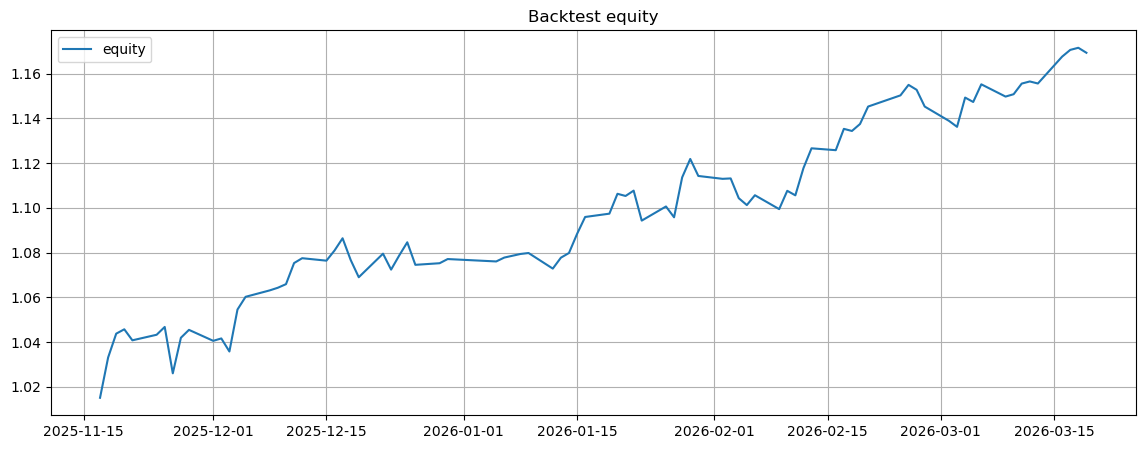

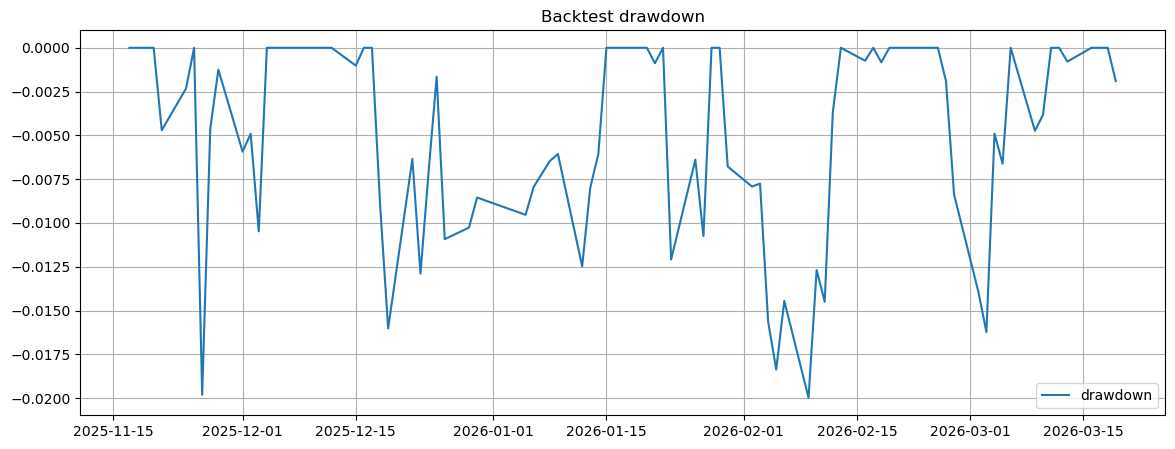

In [36]:
cat_bt = backtest_probs(
    proba_long=test_probs_cat,
    fwd_ret=test['fwd_ret'].values,
    date=test['date'].values,
    lower=threshold - 1e-9,
    upper=threshold + 1e-9,
    cost_bps=10,
    ret_type='log'
)

print_bt_report(cat_bt)
# cat_bt['yearly']
plot_bt(cat_bt)

In [37]:
df, summ = fearure_importance(cat, features_final, n=15)
print(summ)
df

ValueError: All arrays must be of the same length

In [ ]:
top_15_features = list(df['feature'].values)